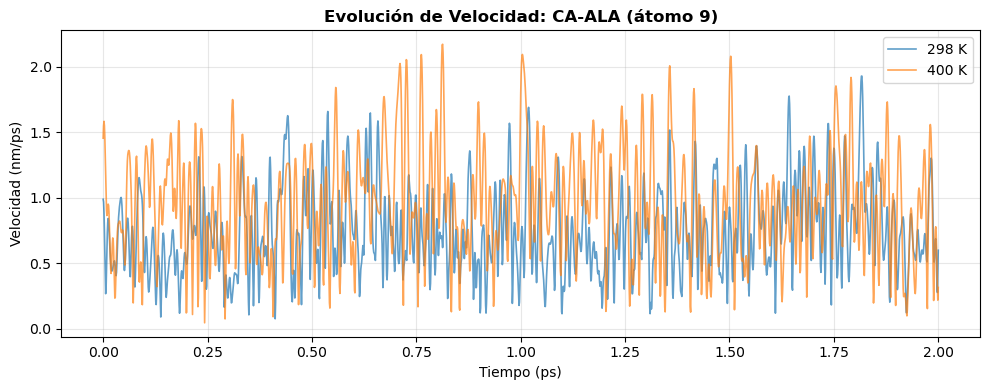

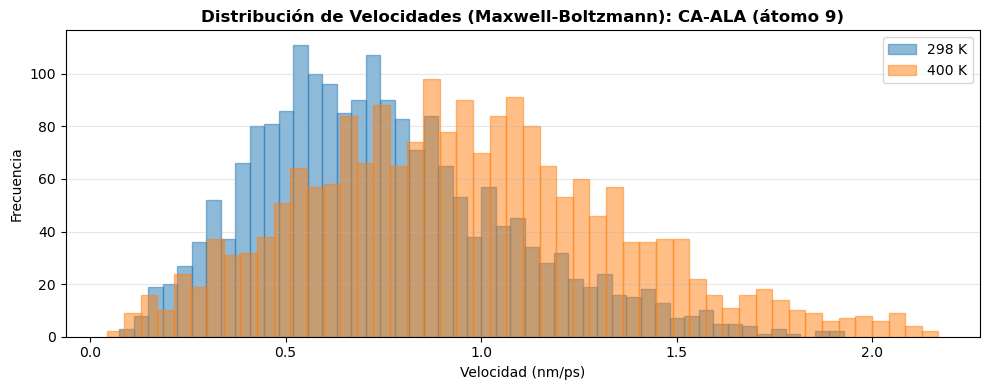

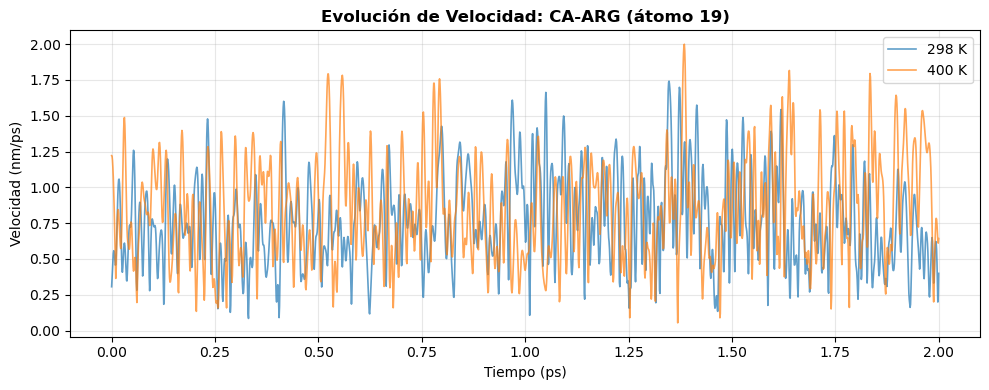

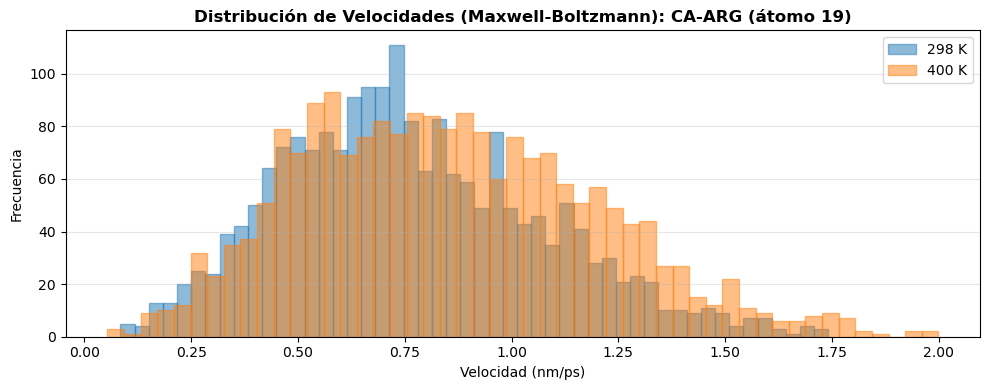

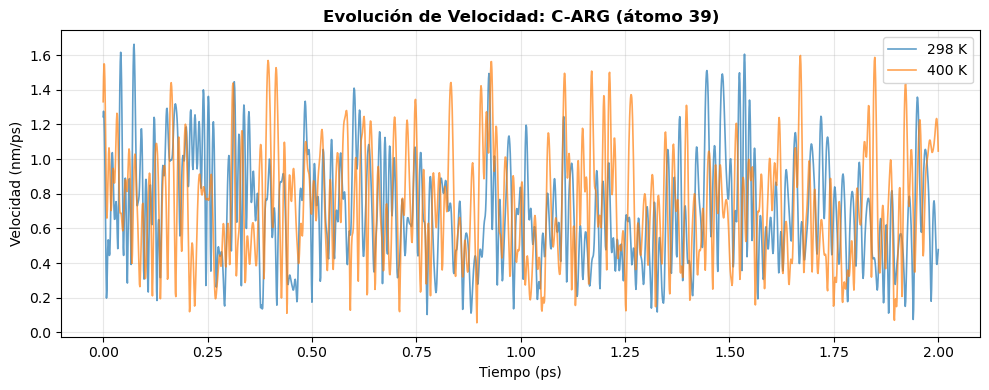

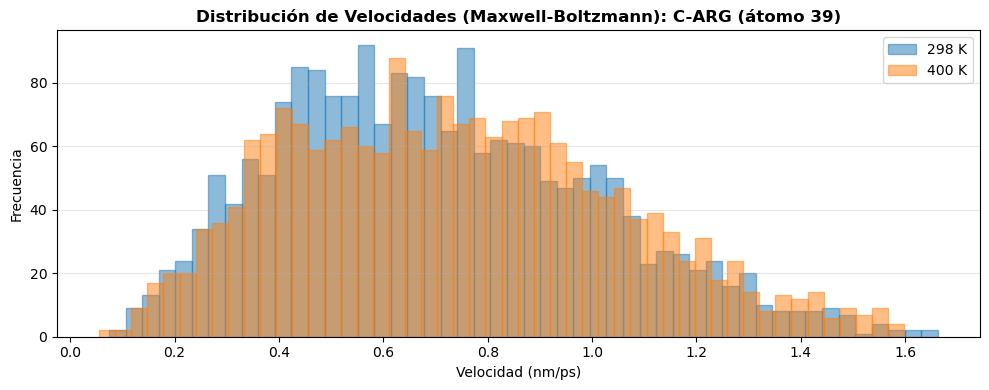

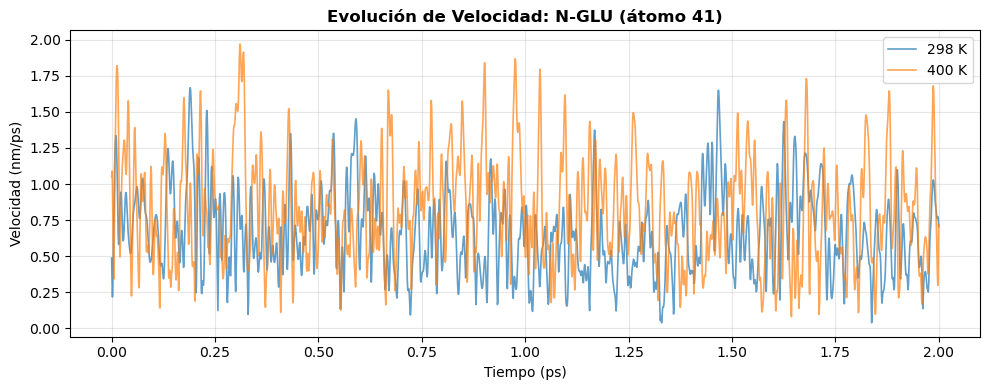

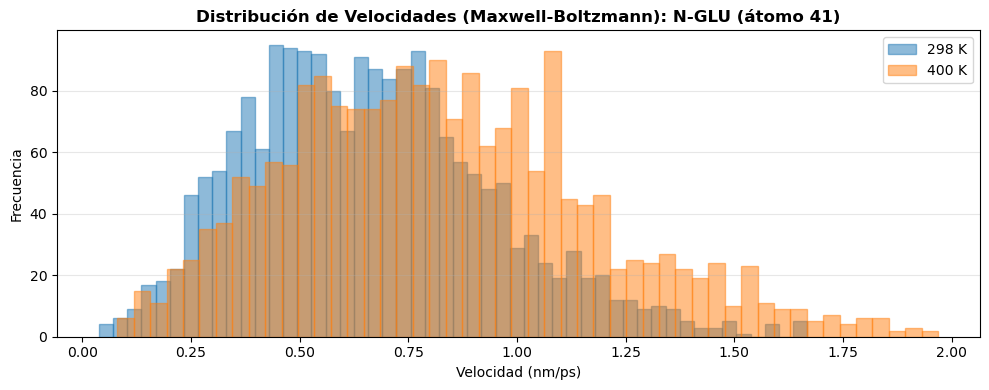

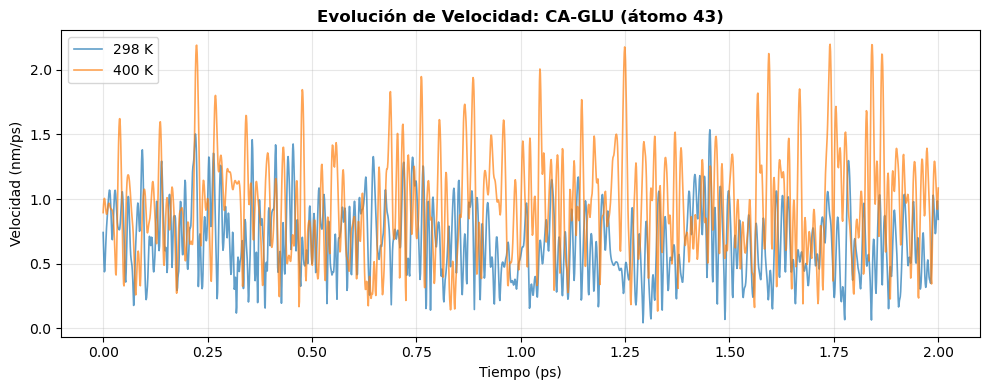

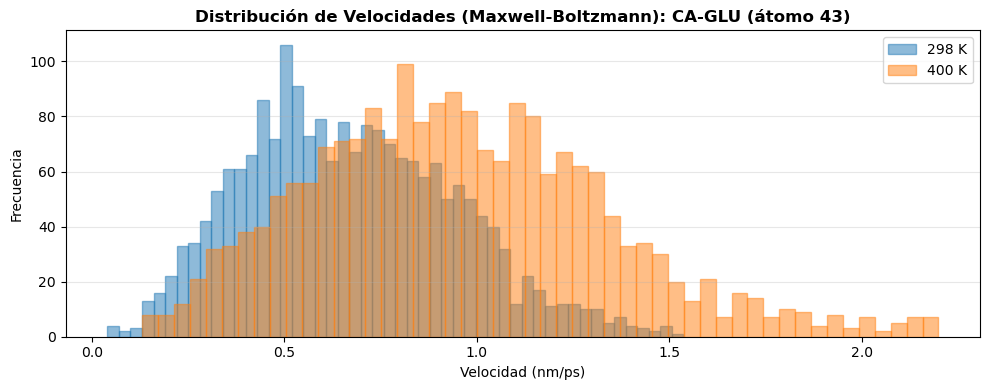

In [1]:
import numpy as np
import matplotlib.pyplot as plt

#Rutas y configuración
files = [
    "/home/alumno23/MM/for-students/TAREA_PERFECTA/4-analysis/analysis_298K/veloc.xvg",
    "/home/alumno23/MM/for-students/TAREA_PERFECTA/4-analysis/analysis_400K/veloc.xvg"
]
labels_atoms = ["CA-ALA (átomo 9)", "CA-ARG (átomo 19)", "C-ARG (átomo 39)", "N-GLU (átomo 41)", "CA-GLU (átomo 43)"]
colors = ['tab:blue', 'tab:orange']
temps = ["298 K", "400 K"]

#Carga de ambos archivos en una lista
datasets = [np.loadtxt(f, comments=('@', '#')) for f in files]
time = datasets[0][:, 0] 

for i, atom_name in enumerate(labels_atoms):
    # El índice de la columna |v| es: 1 (tiempo) + (i * 4 columnas por átomo) + 3 (módulo v)
    v_idx = 1 + i * 4 + 3
    velocities = [data[:, v_idx] for data in datasets]

    #EVOLUCIÓN TEMPORAL
    plt.figure(figsize=(10, 4))
    for v, col, lab in zip(velocities, colors, temps):
        plt.plot(time, v, label=lab, color=col, lw=1.2, alpha=0.7)
    
    plt.title(f"Evolución de Velocidad: {atom_name}", fontweight='bold')
    plt.xlabel("Tiempo (ps)"); plt.ylabel("Velocidad (nm/ps)")
    plt.legend(); plt.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

    #HISTOGRAMA COMPARATIVO
    plt.figure(figsize=(10, 4))
    for v, col, lab in zip(velocities, colors, temps):
        plt.hist(v, bins=50, color=col, alpha=0.5, label=lab, edgecolor=col)
    
    plt.title(f"Distribución de Velocidades (Maxwell-Boltzmann): {atom_name}", fontweight='bold')
    plt.xlabel("Velocidad (nm/ps)"); plt.ylabel("Frecuencia")
    plt.legend(); plt.grid(axis='y', alpha=0.3)
    plt.tight_layout(); plt.show()

Si se quisiera representar todo junto:

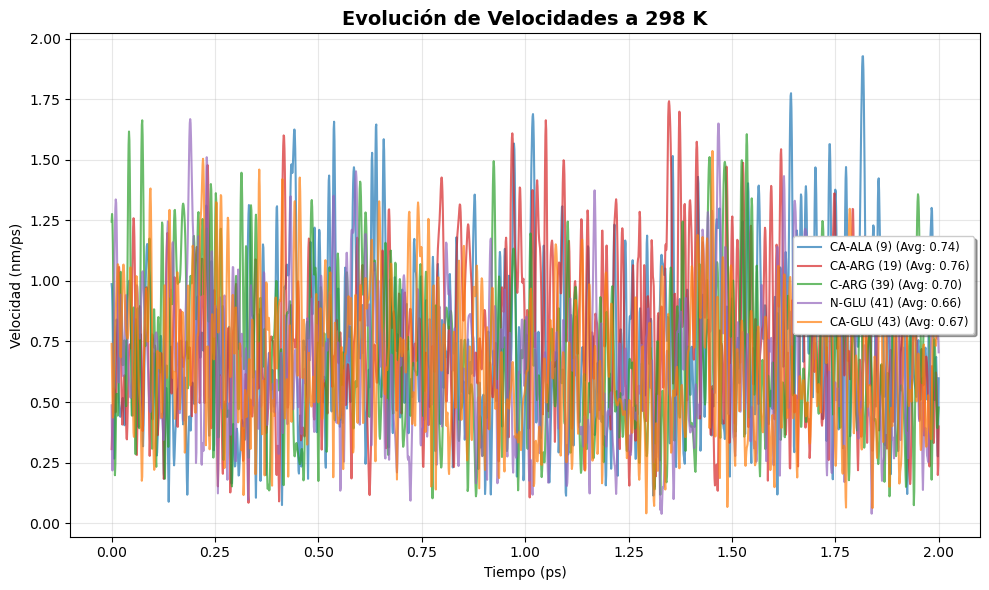

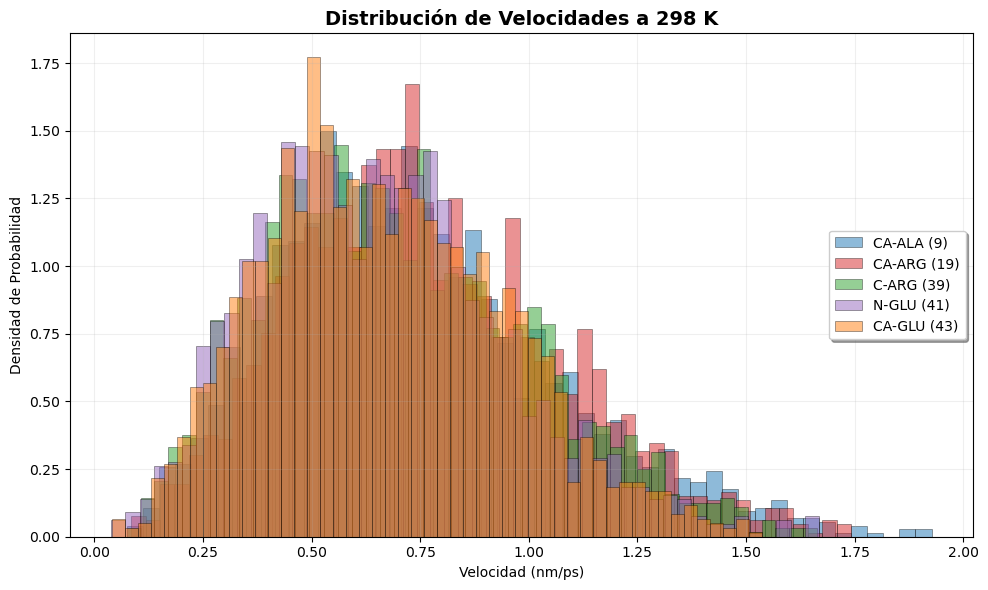

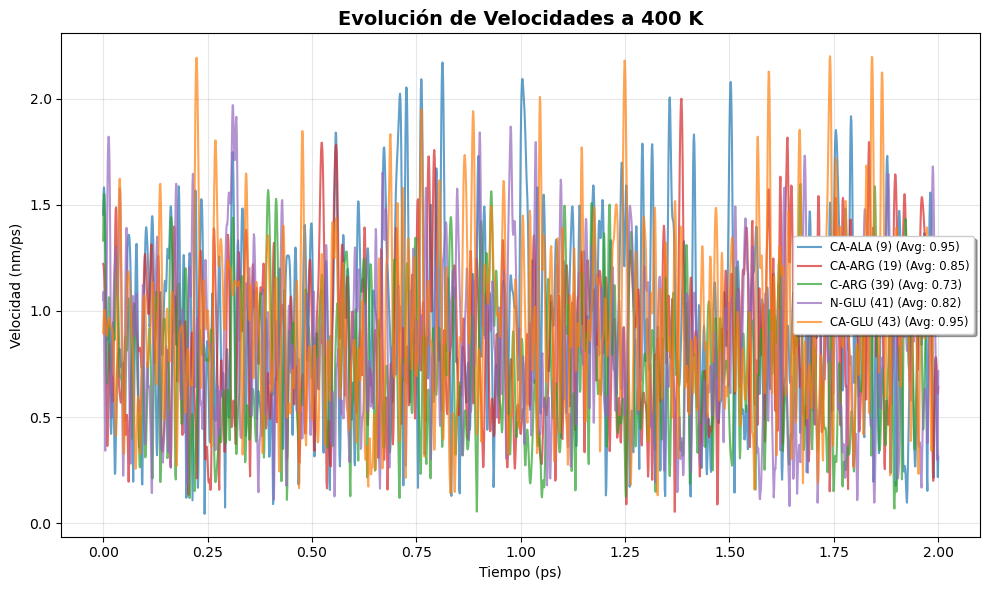

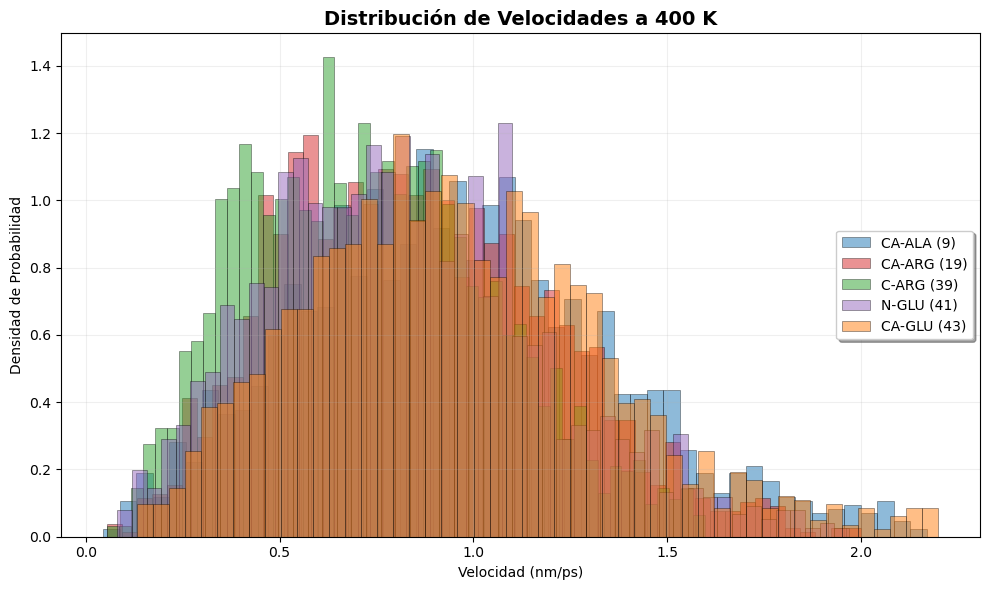

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os

file_298 = "/home/alumno23/MM/for-students/TAREA_PERFECTA/4-analysis/analysis_298K/veloc.xvg"
file_400 = "/home/alumno23/MM/for-students/TAREA_PERFECTA/4-analysis/analysis_400K/veloc.xvg"

# Etiquetas y colores
labels_atoms = ["CA-ALA (9)", "CA-ARG (19)", "C-ARG (39)", "N-GLU (41)", "CA-GLU (43)"]
colors_atoms = ["tab:blue", "tab:red", "tab:green", "tab:purple", "tab:orange"]

def plot_velocity(file, temp, output_file):
    if not os.path.exists(file):
        print(f"Error: {file} no encontrado."); return
    
    # Cargar datos (Col 0: tiempo, Col 1..N: velocidades)
    data = np.loadtxt(file, comments=('@', '#'))
    time = data[:, 0]
    
    plt.figure(figsize=(10, 6))
    
    for i, name in enumerate(labels_atoms):
        # Índice: 1 (tiempo) + (i * 4 columnas) + 3 (módulo de velocidad)
        vmag_idx = 1 + i * 4 + 3
        vmag = data[:, vmag_idx]
        
        # Calculamos la media para ponerla en la leyenda
        v_mean = np.mean(vmag)
        plt.plot(time, vmag, label=f"{name} (Avg: {v_mean:.2f})", color=colors_atoms[i], lw=1.5, alpha=0.7)
    
    plt.title(f'Evolución de Velocidades a {temp} K', fontweight='bold', fontsize=14)
    plt.xlabel('Tiempo (ps)')
    plt.ylabel('Velocidad (nm/ps)')
    
    # Ajuste: Leyenda al centro derecha
    plt.legend(loc='center right', shadow=True, fontsize='small')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    
    plt.show()

def plot_histogram(file, temp, output_file):
    if not os.path.exists(file): return
    
    data = np.loadtxt(file, comments=('@', '#'))
    
    plt.figure(figsize=(10, 6))
    
    for i, name in enumerate(labels_atoms):
        vmag_idx = 1 + i * 4 + 3
        vmag = data[:, vmag_idx]
        
        plt.hist(vmag, bins=50, color=colors_atoms[i], alpha=0.5, 
                 label=name, edgecolor='black', linewidth=0.5, density=True)
    
    # Formato "Gordito"
    plt.title(f'Distribución de Velocidades a {temp} K', fontweight='bold', fontsize=14)
    plt.xlabel("Velocidad (nm/ps)")
    plt.ylabel("Densidad de Probabilidad")
    plt.legend(loc='center right', shadow=True)
    plt.grid(alpha=0.2)
    plt.tight_layout()
    
    plt.show()

#EJECUCIÓN DEL SCRIPT 
#Procesar 298 K
plot_velocity(file_298, 298, 'velocities_298K.png')
plot_histogram(file_298, 298, 'histograma_298K.png')

#Procesar 400 K
plot_velocity(file_400, 400, 'velocities_400K.png')
plot_histogram(file_400, 400, 'histograma_400K.png')
